Anggota :
* Muhammad Muafi (164221092)
* Herman Effendi (164221056)
* Andreas Hendra Herwantob (164221064)
* Pradipta Deska Pryanda4 (164221108)



# Library

In [ ]:
import numpy as np
import scipy.linalg
from copy import deepcopy
from threading import Lock
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


# Import Data

In [ ]:
path = "/content/Data_Measles_2004_2024.csv"
df = pd.read_csv(path)
df.head()

,Year,Measles_Reported_cases,WUENIC_Measles_containing vaccine_1st_dose(%),WUENIC_Measles_containing vaccine_2nd_dose(%)
0,2024,"6,328",85,82
1,2023,"18,063",82,69
2,2022,"7,704",92,71
3,2021,394,72,53
4,2020,524,76,60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   Year                                           21 non-null     int64 
 1   Measles_Reported_cases                         21 non-null     object
 2   WUENIC_Measles_containing vaccine_1st_dose(%)  21 non-null     int64 
 3   WUENIC_Measles_containing vaccine_2nd_dose(%)  21 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 804.0+ bytes


In [ ]:
df.describe()

,Year,Measles_Reported_cases,WUENIC_Measles_containing vaccine_1st_dose(%),WUENIC_Measles_containing vaccine_2nd_dose(%)
count,21.000000,21.000000,21.000000,21.000000
mean,2014.000000,12860.761905,81.904762,60.095238
std,6.204837,7822.570677,6.007535,18.055206
min,2004.000000,394.000000,72.000000,23.000000
25%,2009.000000,6962.000000,76.000000,53.000000
50%,2014.000000,15099.000000,82.000000,67.000000
75%,2019.000000,18869.000000,87.000000,73.000000
max,2024.000000,29171.000000,92.000000,82.000000


In [ ]:
df["Measles_Reported_cases"] = (df["Measles_Reported_cases"].astype(str).str.replace(",", "", regex=False).astype(float))

In [ ]:
# Pastikan urut waktu (lama -> baru)
df = df.sort_values("Year").reset_index(drop=True)

years = df["Year"].astype(int).to_numpy()
cases = df["Measles_Reported_cases"].to_numpy()

# Exogenous inputs (cakupan vaksin)
v1 = df["WUENIC_Measles_containing vaccine_1st_dose(%)"].astype(float).to_numpy()
v2 = df["WUENIC_Measles_containing vaccine_2nd_dose(%)"].astype(float).to_numpy()

# Centering supaya lebih stabil (mengurangi masalah skala)
v1_c = v1 - np.nanmean(v1)
v2_c = v2 - np.nanmean(v2)

# Observasi (measurement) = log1p(cases)
y_obs = np.log1p(cases)

# Time step tahunan
dt = 1.0

# EDA

In [ ]:
df.columns

Index(['Year', 'Measles_Reported_cases',
       'WUENIC_Measles_containing vaccine_1st_dose(%)',
       'WUENIC_Measles_containing vaccine_2nd_dose(%)'],
      dtype='object')

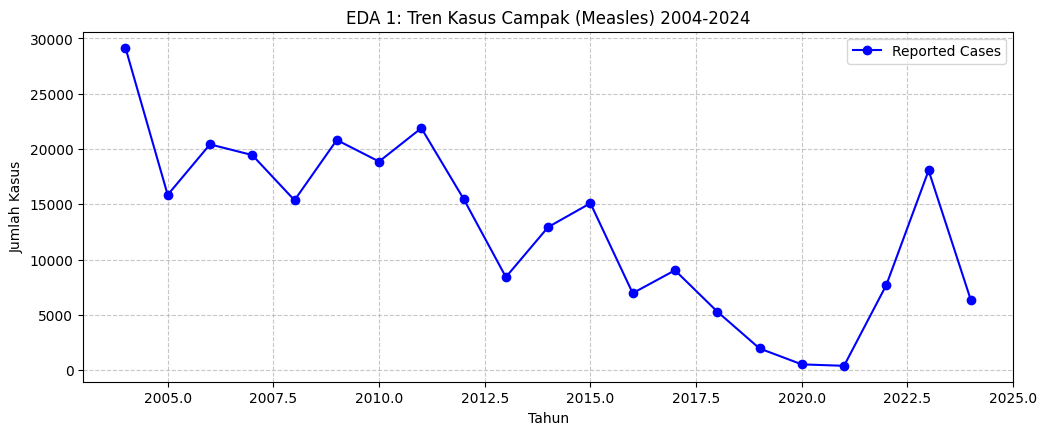

In [ ]:
plt.figure(figsize=(12, 10))

# Subplot 1: Cases
plt.subplot(2, 1, 1)
plt.plot(df['Year'], df['Measles_Reported_cases'], marker='o', color='b', label='Reported Cases')
plt.title('EDA 1: Tren Kasus Campak (Measles) 2004-2024')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Kasus')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


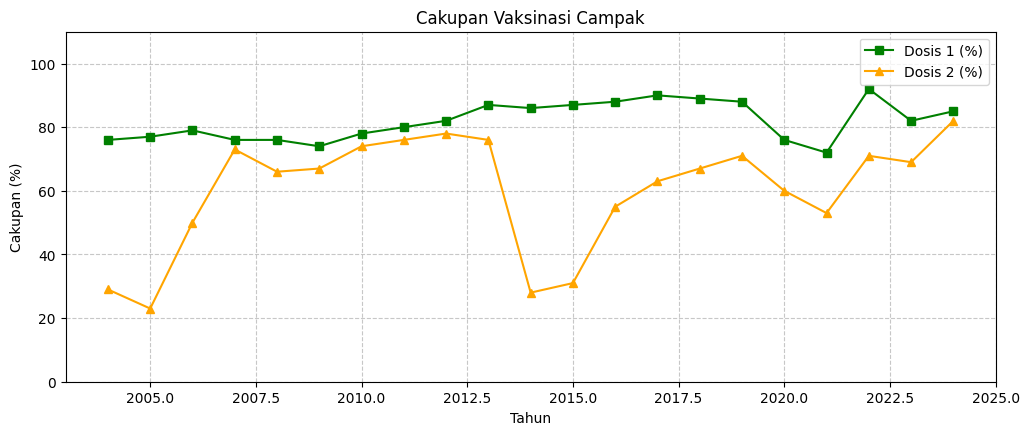

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 2)
plt.plot(df['Year'], df['WUENIC_Measles_containing vaccine_1st_dose(%)'], marker='s', color='g', label='Dosis 1 (%)')
plt.plot(df['Year'], df['WUENIC_Measles_containing vaccine_2nd_dose(%)'], marker='^', color='orange', label='Dosis 2 (%)')
plt.title('Cakupan Vaksinasi Campak')
plt.xlabel('Tahun')
plt.ylabel('Cakupan (%)')
plt.ylim(0, 110)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

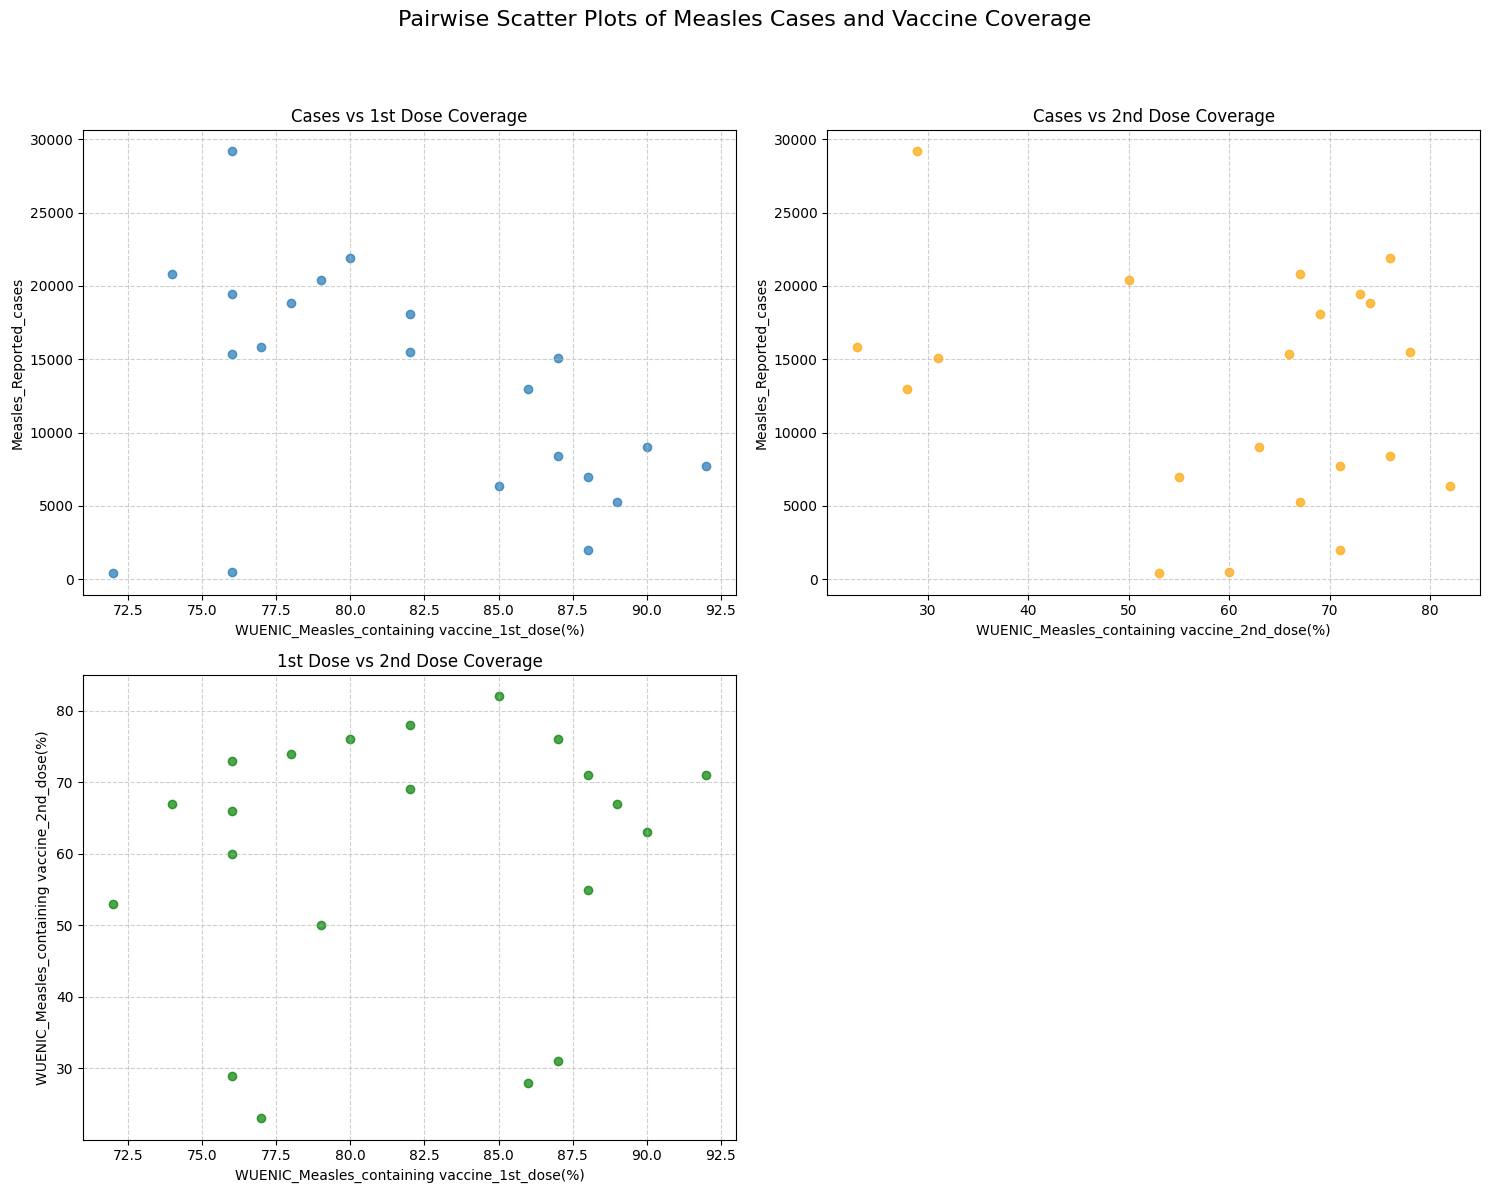

In [ ]:
columns_to_analyze = [
    'Measles_Reported_cases',
    'WUENIC_Measles_containing vaccine_1st_dose(%)',
    'WUENIC_Measles_containing vaccine_2nd_dose(%)'
]

plt.figure(figsize=(15, 12))
plt.suptitle('Pairwise Scatter Plots of Measles Cases and Vaccine Coverage', fontsize=16, y=1.02)

# Plot 1: Measles_Reported_cases vs WUENIC_Measles_containing vaccine_1st_dose(%)
plt.subplot(2, 2, 1)
plt.scatter(df[columns_to_analyze[1]], df[columns_to_analyze[0]], alpha=0.7)
plt.title('Cases vs 1st Dose Coverage')
plt.xlabel('WUENIC_Measles_containing vaccine_1st_dose(%)')
plt.ylabel('Measles_Reported_cases')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Measles_Reported_cases vs WUENIC_Measles_containing vaccine_2nd_dose(%)
plt.subplot(2, 2, 2)
plt.scatter(df[columns_to_analyze[2]], df[columns_to_analyze[0]], alpha=0.7, color='orange')
plt.title('Cases vs 2nd Dose Coverage')
plt.xlabel('WUENIC_Measles_containing vaccine_2nd_dose(%)')
plt.ylabel('Measles_Reported_cases')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: WUENIC_Measles_containing vaccine_1st_dose(%) vs WUENIC_Measles_containing vaccine_2nd_dose(%)
plt.subplot(2, 2, 3)
plt.scatter(df[columns_to_analyze[1]], df[columns_to_analyze[2]], alpha=0.7, color='green')
plt.title('1st Dose vs 2nd Dose Coverage')
plt.xlabel('WUENIC_Measles_containing vaccine_1st_dose(%)')
plt.ylabel('WUENIC_Measles_containing vaccine_2nd_dose(%)')
plt.grid(True, linestyle='--', alpha=0.6)

# The fourth subplot (2,2,4) will remain empty as there are only 3 unique pairwise combinations.
# You can uncomment the following lines if you want to explicitly hide it or add text.
# plt.subplot(2, 2, 4)
# plt.axis('off')
# plt.text(0.5, 0.5, 'No plot here', horizontalalignment='center', verticalalignment='center', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

# Pipeline Helper

In [ ]:
class UKFException(Exception):
    """Raise for errors in the UKF, usually due to bad inputs"""

class UKF:
    def __init__(self, num_states, process_noise, initial_state, initial_covar, alpha, k, beta, iterate_function):
        """
        Initializes the unscented kalman filter
        :param num_states: int, the size of the state
        :param process_noise: the process noise covariance per unit time, should be num_states x num_states
        :param initial_state: initial values for the states, should be num_states x 1
        :param initial_covar: initial covariance matrix, should be num_states x num_states, typically large and diagonal
        :param alpha: UKF tuning parameter, determines spread of sigma points, typically a small positive value
        :param k: UKF tuning parameter, typically 0 or 3 - num_states
        :param beta: UKF tuning parameter, beta = 2 is ideal for gaussian distributions
        :param iterate_function: function that predicts the next state
                    takes in a num_states x 1 state and a float timestep
                    returns a num_states x 1 state
        """
        self.n_dim = int(num_states)
        self.n_sig = 1 + num_states * 2
        self.q = process_noise
        self.x = initial_state
        self.p = initial_covar
        self.beta = beta
        self.alpha = alpha
        self.k = k
        self.iterate = iterate_function

        self.lambd = pow(self.alpha, 2) * (self.n_dim + self.k) - self.n_dim

        self.covar_weights = np.zeros(self.n_sig)
        self.mean_weights = np.zeros(self.n_sig)

        self.covar_weights[0] = (self.lambd / (self.n_dim + self.lambd)) + (1 - pow(self.alpha, 2) + self.beta)
        self.mean_weights[0] = (self.lambd / (self.n_dim + self.lambd))

        for i in range(1, self.n_sig):
            self.covar_weights[i] = 1 / (2*(self.n_dim + self.lambd))
            self.mean_weights[i] = 1 / (2*(self.n_dim + self.lambd))

        self.sigmas = self.__get_sigmas()

        self.lock = Lock()

    def __get_sigmas(self):
        """generates sigma points"""
        ret = np.zeros((self.n_sig, self.n_dim))

        tmp_mat = (self.n_dim + self.lambd)*self.p

        # print spr_mat
        spr_mat = scipy.linalg.sqrtm(tmp_mat)

        ret[0] = self.x
        for i in range(self.n_dim):
            ret[i+1] = self.x + spr_mat[i]
            ret[i+1+self.n_dim] = self.x - spr_mat[i]

        return ret.T

    def update(self, states, data, r_matrix):
        """
        performs a measurement update
        :param states: list of indices (zero-indexed) of which states were measured, that is, which are being updated
        :param data: list of the data corresponding to the values in states
        :param r_matrix: error matrix for the data, again corresponding to the values in states
        """

        self.lock.acquire()

        num_states = len(states)

        # create y, sigmas of just the states that are being updated
        sigmas_split = np.split(self.sigmas, self.n_dim)
        y = np.concatenate([sigmas_split[i] for i in states])

        # create y_mean, the mean of just the states that are being updated
        x_split = np.split(self.x, self.n_dim)
        y_mean = np.concatenate([x_split[i] for i in states])

        # differences in y from y mean
        y_diff = deepcopy(y)
        x_diff = deepcopy(self.sigmas)
        for i in range(self.n_sig):
            for j in range(num_states):
                y_diff[j][i] -= y_mean[j]
            for j in range(self.n_dim):
                x_diff[j][i] -= self.x[j]

        # covariance of measurement
        p_yy = np.zeros((num_states, num_states))
        for i, val in enumerate(np.array_split(y_diff, self.n_sig, 1)):
            p_yy += self.covar_weights[i] * val.dot(val.T)

        # add measurement noise
        p_yy += r_matrix

        # covariance of measurement with states
        p_xy = np.zeros((self.n_dim, num_states))
        for i, val in enumerate(zip(np.array_split(y_diff, self.n_sig, 1), np.array_split(x_diff, self.n_sig, 1))):
            p_xy += self.covar_weights[i] * val[1].dot(val[0].T)

        k = np.dot(p_xy, np.linalg.inv(p_yy))

        y_actual = data

        self.x += np.dot(k, (y_actual - y_mean))
        self.p -= np.dot(k, np.dot(p_yy, k.T))
        self.sigmas = self.__get_sigmas()

        self.lock.release()

    def predict(self, timestep, inputs=[]):
        """
        performs a prediction step
        :param timestep: float, amount of time since last prediction
        """

        self.lock.acquire()

        sigmas_out = np.array([self.iterate(x, timestep, inputs) for x in self.sigmas.T]).T

        x_out = np.zeros(self.n_dim)

        # for each variable in X
        for i in range(self.n_dim):
            # the mean of that variable is the sum of
            # the weighted values of that variable for each iterated sigma point
            x_out[i] = sum((self.mean_weights[j] * sigmas_out[i][j] for j in range(self.n_sig)))

        p_out = np.zeros((self.n_dim, self.n_dim))
        # for each sigma point
        for i in range(self.n_sig):
            # take the distance from the mean
            # make it a covariance by multiplying by the transpose
            # weight it using the calculated weighting factor
            # and sum
            diff = sigmas_out.T[i] - x_out
            diff = np.atleast_2d(diff)
            p_out += self.covar_weights[i] * np.dot(diff.T, diff)

        # add process noise
        p_out += timestep * self.q

        self.sigmas = sigmas_out
        self.x = x_out
        self.p = p_out

        self.lock.release()

    def get_state(self, index=-1):
        """
        returns the current state (n_dim x 1), or a particular state variable (float)
        :param index: optional, if provided, the index of the returned variable
        :return:
        """
        if index >= 0:
            return self.x[index]
        else:
            return self.x

    def get_covar(self):
        """
        :return: current state covariance (n_dim x n_dim)
        """
        return self.p

    def set_state(self, value, index=-1):
        """
        Overrides the filter by setting one variable of the state or the whole state
        :param value: the value to put into the state (1 x 1 or n_dim x 1)
        :param index: the index at which to override the state (-1 for whole state)
        """
        with self.lock:
            if index != -1:
                self.x[index] = value
            else:
                self.x = value

    def reset(self, state, covar):
        """
        Restarts the UKF at the given state and covariance
        :param state: n_dim x 1
        :param covar: n_dim x n_dim
        """

        with self.lock:
            self.x = state
            self.p = covar

In [ ]:
# ------------------------------------------------------------
# 2) DEFINE ITERATE FUNCTION (STATE TRANSITION)
#    state x = [level, trend, b1, b2]
#    inputs = [v1_centered, v2_centered]
# ------------------------------------------------------------
def iterate_fn(x, timestep, inputs):
    """
    x: shape (4,)
    inputs: [v1_c, v2_c] for current time
    """
    level, trend, b1, b2 = x
    u1, u2 = inputs  # exogenous

    # Local linear trend + exogenous effect
    level_next = level + trend * timestep + b1 * u1 * timestep + b2 * u2 * timestep

    # Random walk for parameters (UKF will handle uncertainty via Q)
    trend_next = trend
    b1_next = b1
    b2_next = b2

    return np.array([level_next, trend_next, b1_next, b2_next], dtype=float)

# UKF

In [ ]:
# ------------------------------------------------------------
# 3) INITIALIZE UKF
#    (gunakan class UKF Anda persis seperti yang Anda kirim)
# ------------------------------------------------------------
# Pastikan class UKF sudah ada di environment (copy-paste dari Anda),
# lalu lanjutkan bagian ini.

n = 4  # [level, trend, b1, b2]

# Initial state:
level0 = y_obs[0]
trend0 = (y_obs[1] - y_obs[0]) if len(y_obs) > 1 else 0.0
b10 = 0.0
b20 = 0.0
x0 = np.array([level0, trend0, b10, b20], dtype=float)

# Initial covariance (buat cukup besar untuk parameter yang belum yakin)
P0 = np.diag([1.0, 0.5, 0.05, 0.05])

# Process noise per unit time (Q)
# - level & trend: agak lebih besar
# - b1 & b2: kecil (biar tidak “liar”)
Q = np.diag([0.15, 0.10, 0.005, 0.005])

# UKF tuning
alpha = 1e-3
kappa = 0
beta = 2

ukf = UKF(
    num_states=n,
    process_noise=Q,
    initial_state=x0,
    initial_covar=P0,
    alpha=alpha,
    k=kappa,
    beta=beta,
    iterate_function=iterate_fn
)

# Measurement noise R (karena measurement hanya 1 variabel: level)
# Bisa Anda tuning; makin besar -> filter makin “tidak percaya” data.
R = np.array([[0.25]])

In [ ]:
# ------------------------------------------------------------
# 4) FILTERING LOOP (PREDICT + UPDATE)
# ------------------------------------------------------------
x_filt = []
P_filt = []
y_hat = []

for t in range(len(df)):
    # predict step (pakai inputs exogenous untuk tahun t)
    ukf.predict(timestep=dt, inputs=[v1_c[t], v2_c[t]])

    # update step (kita mengukur state "level" yaitu index 0)
    # states=[0] berarti hanya state ke-0 yang di-update pakai measurement
    ukf.update(states=[0], data=np.array([y_obs[t]]), r_matrix=R)

    x_now = ukf.get_state()
    P_now = ukf.get_covar()

    x_filt.append(x_now.copy())
    P_filt.append(P_now.copy())

    y_hat.append(x_now[0])  # estimated level

x_filt = np.array(x_filt)   # shape: (T, 4)
y_hat = np.array(y_hat)     # shape: (T,)

# Convert back to cases
cases_hat = np.expm1(y_hat)

In [ ]:
# ------------------------------------------------------------
# 5) OPTIONAL: FORECAST NEXT K YEARS
# ------------------------------------------------------------
K = 3  # forecast 3 tahun ke depan (ubah sesuai kebutuhan)
last_year = years[-1]

# Untuk forecasting, kalau tidak punya input vaksin masa depan,
# gunakan asumsi: vaksin tetap pada nilai terakhir.
v1_future = v1_c[-1]
v2_future = v2_c[-1]

x_fore = []
y_fore = []
year_fore = []

for i in range(1, K + 1):
    ukf.predict(timestep=dt, inputs=[v1_future, v2_future])
    x_pred = ukf.get_state()
    x_fore.append(x_pred.copy())
    y_fore.append(x_pred[0])
    year_fore.append(last_year + i)

x_fore = np.array(x_fore)
cases_fore = np.expm1(np.array(y_fore))

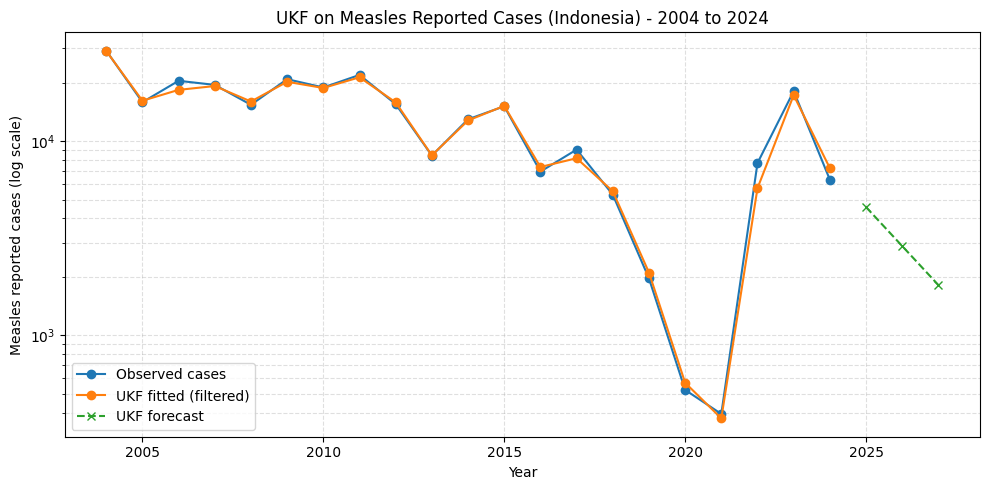

In [ ]:
# ------------------------------------------------------------
# 6) PLOT
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(years, cases, marker="o", label="Observed cases")
plt.plot(years, cases_hat, marker="o", label="UKF fitted (filtered)")

plt.plot(year_fore, cases_fore, marker="x", linestyle="--", label="UKF forecast")

plt.yscale("log")  # kasus sering sangat skew; log membantu visual
plt.xlabel("Year")
plt.ylabel("Measles reported cases (log scale)")
plt.title("UKF on Measles Reported Cases (Indonesia) - 2004 to 2024")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 7) OUTPUT RINGKAS PARAMETER (OPSIONAL)
# ------------------------------------------------------------
print("Last filtered state [level, trend, b1, b2]:", x_filt[-1])
print("Interpretable notes:")
print("- trend > 0 berarti kecenderungan level log(cases) naik per tahun")
print("- b1/b2 < 0 berarti vaksin coverage naik -> kasus cenderung turun (di level log)")

Last filtered state [level, trend, b1, b2]: [ 8.88977491  0.42743102  0.17525347 -0.06535932]
Interpretable notes:
- trend > 0 berarti kecenderungan level log(cases) naik per tahun
- b1/b2 < 0 berarti vaksin coverage naik -> kasus cenderung turun (di level log)


In [ ]:
# ===============================
# PREPARATION
# ===============================
# Pastikan data valid
mask = (~np.isnan(cases)) & (~np.isnan(cases_hat)) & (cases >= 0)

y_true = cases[mask]
y_pred = cases_hat[mask]

# ===============================
# RMSE
# ===============================
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# ===============================
# NRMSE
# (dinormalisasi dengan range data aktual)
# ===============================
nrmse = rmse / (y_true.max() - y_true.min())

# ===============================
# MAPE
# (hindari pembagian nol)
# ===============================
mape = np.mean(
    np.abs((y_true - y_pred) / np.maximum(y_true, 1))
) * 100

# ===============================
# OUTPUT
# ===============================
print("=== Evaluasi Kinerja Unscented Kalman Filter (UKF) ===")
print(f"RMSE  : {rmse:,.2f} kasus")
print(f"NRMSE : {nrmse:.4f}")
print(f"MAPE  : {mape:.2f} %")


=== Evaluasi Kinerja Unscented Kalman Filter (UKF) ===
RMSE  : 763.79 kasus
NRMSE : 0.0265
MAPE  : 5.41 %


In [ ]:
import numpy as np

# Ambil varians latent incidence level
variances = np.array([P[0, 0] for P in P_filt])
mean_variance = variances.mean()
min_variance = variances.min()
max_variance = variances.max()



In [ ]:
mean_variance


np.float64(0.38147664207410276)

In [ ]:
min_variance


np.float64(0.36566525134908967)

In [ ]:
max_variance

np.float64(0.3987943440794339)

In [ ]:
P_filt[t][0,0]


np.float64(0.39040966807723)